# Notebook 01 — Ingestão, Profiling e Visão Espacial das Bases de Endereços

## Contextualização na Dissertação

Este notebook constitui a **primeira etapa do pipeline reprodutível** desta dissertação de Mestrado em Ciência da Computação (UFMG), cujo objetivo central é avaliar a qualidade e a incerteza posicional do Cadastro Nacional de Endereços para Fins Estatísticos — **CNEFE 2022** (IBGE) — confrontando-o com uma base de referência municipal de alta confiabilidade: o **BHMap Endereços** (Prefeitura de Belo Horizonte).

A motivação metodológica ancora-se na abordagem de Davis Jr. et al. (2011), que identifica a geocodificação de endereços no Brasil como um processo inerentemente desafiador, em razão da **informalidade toponímica**, da **variabilidade ortográfica** e da **ausência de um padrão nacional de endereçamento padronizado**. A avaliação sistemática da qualidade desses dados exige, como pré-requisito, a ingestão rigorosa e o profiling estatístico das fontes primárias — etapa que este notebook endereça.

### Fontes de Dados

| Base | Proveniência | Cobertura | Volume bruto |
|---|---|---|---|
| **CNEFE 2022** | IBGE — Censo Demográfico 2022 | Nacional (filtrado para BH) | ~4.9 GB (CSV) |
| **BHMap Endereços** | PBH — Prodabel / IDE-BH | Belo Horizonte | ~550 mil registros |

### Objetivo

Carregar as bases pré-processadas pelo pipeline ETL (DuckDB), validar a integridade geométrica, gerar perfis estatísticos e produzir uma **visão espacial exploratória** da distribuição dos pontos — passo essencial para contextualizar as análises subsequentes de completude (NB03), acurácia (NB04) e incerteza espacial (NB05–06).


In [1]:
import sys
import os
from pathlib import Path

# Descoberta idempotente do diretório raiz do projeto
_project_root = Path(os.path.abspath('')).parent if Path(os.path.abspath('')).name == 'notebooks' else Path(os.path.abspath(''))
if os.getcwd() != str(_project_root):
    os.chdir(_project_root)
if str(_project_root) not in sys.path:
    sys.path.insert(0, str(_project_root))
%load_ext autoreload
%autoreload 2
import pandas as pd
import geopandas as gpd
from shapely import wkt
import matplotlib.pyplot as plt
from src import config
from src.log_config import logger


## 1. Carregamento do Cache Parquet e Reconstituição Geométrica

Os dados brutos do CNEFE e do BHMap foram previamente processados pelo módulo `etl_pipeline.py`, que executa:

1. **Filtragem territorial** — extração apenas dos registros referentes ao município de Belo Horizonte (código IBGE 3106200)
2. **Padronização canônica** — normalização de colunas segundo o schema definido em `src/config.py`
3. **Geocodificação nativa** — conversão de coordenadas para geometria `POINT` em EPSG:31983 (SIRGAS 2000 / UTM 23S)
4. **Persistência em GeoParquet** — formato colunar otimizado, com compressão Snappy, que preserva metadados CRS

Esta estratégia de materialização em Parquet garante **reprodutibilidade** e **eficiência**: o custo de I/O do CSV bruto de 4.9 GB é incorrido uma única vez.


In [2]:
logger.info("Carregando bases filtradas Parquet...")

# Load pre-filtered parquets using Pandas first (no geo metadata built-in)
df_cnefe = pd.read_parquet(config.CNEFE_PROCESSED_FILE)
df_bhmap = pd.read_parquet(config.BHMAP_PROCESSED_FILE)

# Helper to find geometry column
def get_geom_col(df):
    return 'wkt_geometry' if 'wkt_geometry' in df.columns else 'geometry'

cnefe_geom_col = get_geom_col(df_cnefe)
bhmap_geom_col = get_geom_col(df_bhmap)

try:
    gdf_cnefe_bh = gpd.GeoDataFrame(df_cnefe, geometry=gpd.GeoSeries.from_wkt(df_cnefe[cnefe_geom_col], on_invalid='ignore'), crs='EPSG:4674')
except TypeError:
    gdf_cnefe_bh = gpd.GeoDataFrame(df_cnefe, geometry=cnefe_geom_col, crs='EPSG:4674')
    
try:
    gdf_bhmap = gpd.GeoDataFrame(df_bhmap, geometry=gpd.GeoSeries.from_wkt(df_bhmap[bhmap_geom_col], on_invalid='ignore'), crs=config.DEFAULT_CRS)
except TypeError:
    gdf_bhmap = gpd.GeoDataFrame(df_bhmap, geometry=bhmap_geom_col, crs=config.DEFAULT_CRS)

# Reproject everything to exactly the same metric CRS for precise comparisons in the next steps
gdf_cnefe_bh = gdf_cnefe_bh.to_crs(config.DEFAULT_CRS)
gdf_bhmap = gdf_bhmap.to_crs(config.DEFAULT_CRS)

# Drop redundant wkt columns if any
for col in ['wkt_geometry', 'geometry']:
    if col in gdf_cnefe_bh.columns and col != gdf_cnefe_bh._geometry_column_name:
        gdf_cnefe_bh = gdf_cnefe_bh.drop(columns=[col])
    if col in gdf_bhmap.columns and col != gdf_bhmap._geometry_column_name:
        gdf_bhmap = gdf_bhmap.drop(columns=[col])

logger.info("Dados carregados e projetados no sistema métrico", 
            cnefe_crs=str(gdf_cnefe_bh.crs), 
            bhmap_crs=str(gdf_bhmap.crs))

2026-03-05T19:00:27.438013Z [info     ] Carregando bases filtradas Parquet... [__main__]


2026-03-05T19:00:37.401487Z [info     ] Dados carregados e projetados no sistema métrico [__main__] bhmap_crs=EPSG:31983 cnefe_crs=EPSG:31983


## 2. Schema Canônico e Inspeção Estrutural

A padronização do schema é uma etapa crítica na integração de bases heterogêneas. Conforme Davis Jr. et al. (2011), a **heterogeneidade semântica** — variação na nomenclatura de campos, formatos de CEP, tipos de logradouro — é uma das principais fontes de erro no cruzamento de endereços. O schema canônico adotado neste trabalho define colunas prefixadas com `std_` (standardized), mapeando os atributos originais de ambas as bases para um vocabulário uniforme.

A célula abaixo exibe os primeiros registros das colunas canônicas do CNEFE, permitindo validar visualmente a conformidade do processo de padronização.


In [3]:
display(gdf_cnefe_bh[[c for c in gdf_cnefe_bh.columns if c.startswith('std_')]].head(3))
display(gdf_bhmap[[c for c in gdf_bhmap.columns if c.startswith('std_')]].head(3))

,std_logradouro_completo,std_complemento,std_bairro,std_cep,std_municipio,std_uf
0,"RUA DIALOGITA, 135",CASA A,PARAISO,30270120,BELO HORIZONTE,MG
1,"AVENIDA DOM PEDRO II, 3687",CASA 1,PADRE EUSTAQUIO,30720272,BELO HORIZONTE,MG
2,"RUA DIVINOPOLIS, 225",,SANTA TEREZA,31010370,BELO HORIZONTE,MG


,std_tipo_logradouro,std_nome_logradouro,std_numero,std_complemento_letra,std_bairro,std_cep,std_municipio,std_uf
0,BEC,SERVIDAO,,,VILA MALOCA,,BELO HORIZONTE,MG
1,AVE,PERIMETRAL,,,CASTANHEIRA,,BELO HORIZONTE,MG
2,BEC,DO ARAME UM,,,VILA COPACABANA,,BELO HORIZONTE,MG


## 3. Profiling Estatístico das Bases

Antes de qualquer análise de qualidade, é fundamental produzir um **perfil descritivo** que revele a distribuição, a tipologia e os valores extremos das variáveis de interesse. Este profiling cumpre dupla função:

1. **Diagnóstico de integridade** — identificar campos nulos, outliers geométricos (coordenadas fora de BH) e inconsistências de tipo
2. **Linha de base quantitativa** — estabelecer os parâmetros descritivos (médias, medianas, quartis) que serão confrontados com os resultados do cruzamento

Para cada base, calculamos estatísticas por coluna canônica, incluindo contagem de não-nulos, percentual de preenchimento e comprimento médio das strings de endereço.


In [4]:
def generate_profile(gdf, name):
    stats = []
    canonical_cols = [c for c in gdf.columns if c.startswith('std_')]
    for col in canonical_cols:
        stats.append({
            'Dataset': name,
            'Field': col,
            'Total_Rows': len(gdf),
            'Missing_Count':  gdf[col].isna().sum() + (gdf[col] == '').sum(),
            'Unique_Values': gdf[col].nunique()
        })
    
    df = pd.DataFrame(stats)
    df['Missing_Percentage'] = round((df['Missing_Count'] / df['Total_Rows']) * 100, 2)
    return df

profile_cnefe = generate_profile(gdf_cnefe_bh, 'CNEFE')
profile_bhmap = generate_profile(gdf_bhmap, 'BHMap')
profile_df = pd.concat([profile_cnefe, profile_bhmap])

display(profile_df)

,Dataset,Field,Total_Rows,Missing_Count,Unique_Values,Missing_Percentage
0,CNEFE,std_logradouro_completo,1180102,0,583880,0.00
1,CNEFE,std_complemento,1180102,490086,34929,41.53
2,CNEFE,std_bairro,1180102,0,465,0.00
3,CNEFE,std_cep,1180102,0,13211,0.00
4,CNEFE,std_municipio,1180102,0,1,0.00
5,CNEFE,std_uf,1180102,0,1,0.00
0,BHMap,std_tipo_logradouro,757113,0,18,0.00
1,BHMap,std_nome_logradouro,757113,0,12445,0.00
2,BHMap,std_numero,757113,757113,1,100.00
3,BHMap,std_complemento_letra,757113,626129,36,82.70


## 4. Persistência do Estado Geoespacial

Após a validação, re-exportamos os GeoDataFrames com geometria nativa para GeoParquet. Isso garante que os notebooks subsequentes consumam dados com **CRS explícito** e **geometria vetorial** (não apenas colunas `lat`/`lon` textuais), reduzindo o risco de reprocessamento e de perda de informação espacial (DEVILLERS; JEANSOULIN, 2006).


In [5]:
# Update Parquet files with native GeoParquet representation now that geometry is fixed
gdf_cnefe_bh.to_parquet(config.CNEFE_PROCESSED_FILE)
gdf_bhmap.to_parquet(config.BHMAP_PROCESSED_FILE)

profile_csv_path = config.TABLES_DIR / "01_basic_profile.csv"
profile_df.to_csv(profile_csv_path, index=False)
logger.info("Bases GeoParquet atualizadas via GeoPandas.")

2026-03-05T19:00:43.716305Z [info     ] Bases GeoParquet atualizadas via GeoPandas. [__main__]


## 5. Visão Espacial Exploratória

A visualização da distribuição espacial dos pontos é o passo final deste notebook e cumpre um papel analítico importante: permite identificar, ainda na fase de ingestão, **assimetrias de cobertura** entre as bases. Diferenças na densidade de pontos entre regiões centrais e periféricas podem antecipar padrões que serão confirmados nas análises de acurácia (NB04) e autocorrelação espacial (NB05).

O mapa abaixo plota uma amostra de 50.000 pontos de cada base sobre o basemap CartoDB Positron, em projeção Web Mercator (EPSG:3857). A sobreposição visual permite avaliar a **concordância geográfica** entre CNEFE e BHMap antes do cruzamento formal.


2026-03-05T19:00:53.652685Z [info     ] Figura espacial gerada.        [__main__]


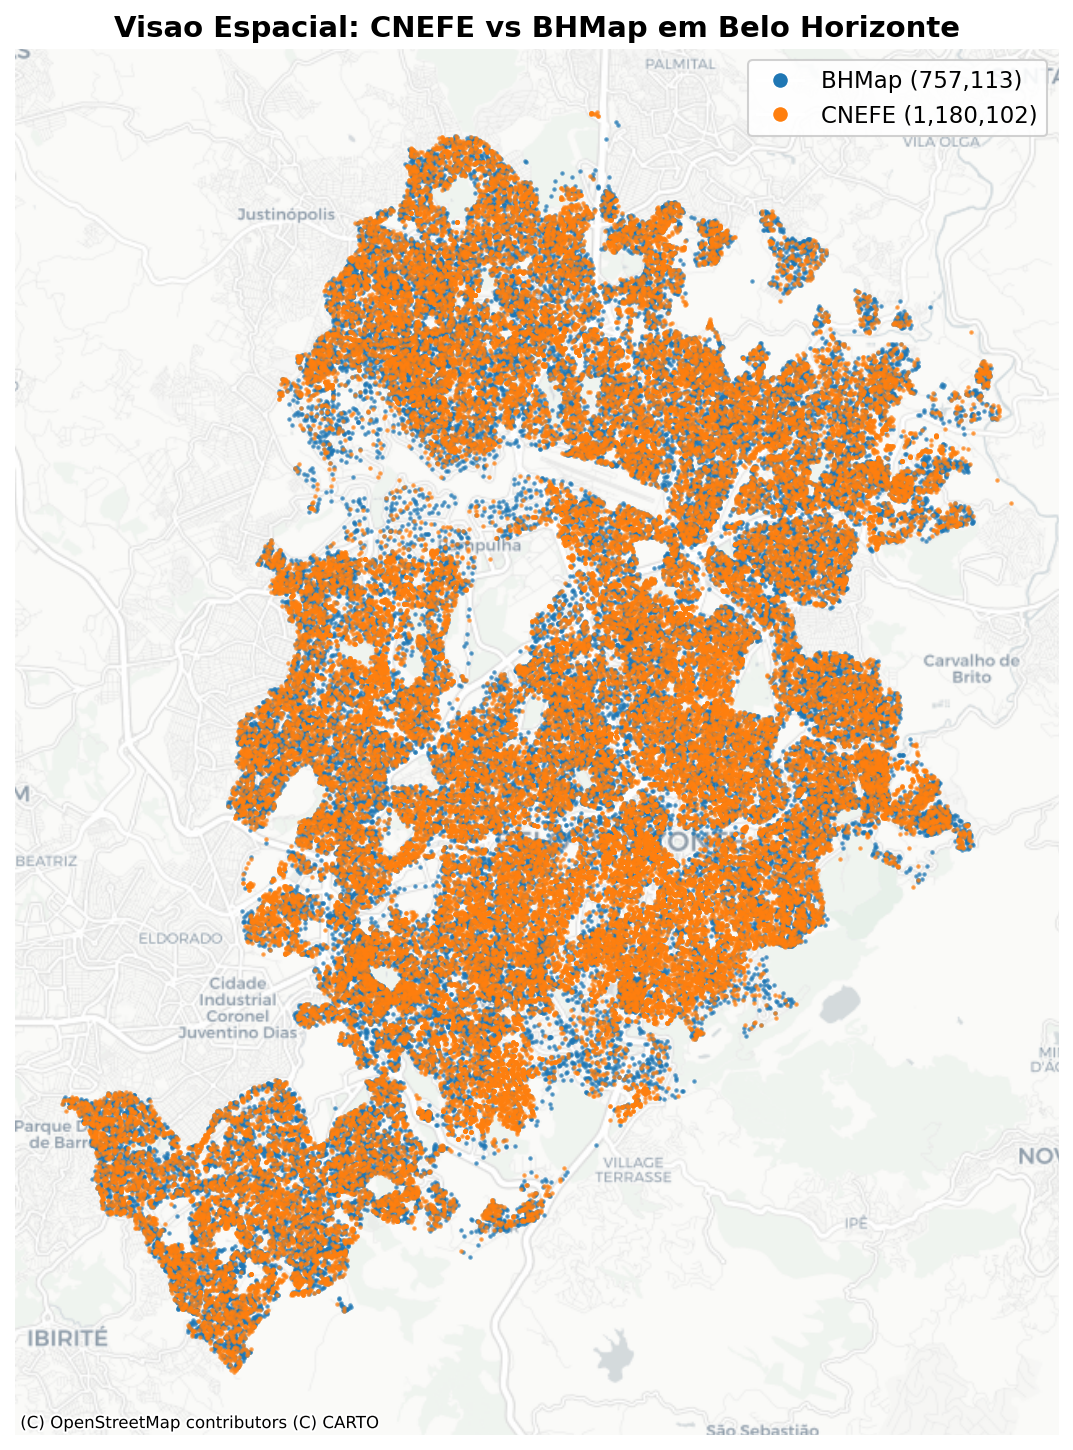

In [6]:
import contextily as cx

# Reprojetar para Web Mercator para exibir com basemap
bhmap_wm = gdf_bhmap.to_crs(epsg=3857)
cnefe_wm = gdf_cnefe_bh.to_crs(epsg=3857)

fig, ax = plt.subplots(figsize=(12, 12), dpi=150)

# Amostrar para performance na visualizacao
sample_n = min(50000, len(bhmap_wm))
bhmap_wm.sample(sample_n, random_state=42).plot(
    ax=ax, markersize=1.5, color='#1f77b4', alpha=0.6
)
sample_n2 = min(50000, len(cnefe_wm))
cnefe_wm.sample(sample_n2, random_state=42).plot(
    ax=ax, markersize=1.5, color='#ff7f0e', alpha=0.6
)

# Basemap CartoDB
try:
    cx.add_basemap(ax, source=cx.providers.CartoDB.Positron)
except Exception as e:
    print(f'Basemap indisponivel: {e}')

# Legenda manual (GeoDataFrame.plot nao propaga label)
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#1f77b4', markersize=8, label=f'BHMap ({len(gdf_bhmap):,})'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#ff7f0e', markersize=8, label=f'CNEFE ({len(gdf_cnefe_bh):,})'),
]
ax.legend(handles=legend_elements, loc='upper right', fontsize=11, framealpha=0.9)

ax.set_title('Visao Espacial: CNEFE vs BHMap em Belo Horizonte', fontsize=14, fontweight='bold')
ax.set_axis_off()

config.FIGURES_DIR.mkdir(parents=True, exist_ok=True)
plt.savefig(config.FIGURES_DIR / '01_spatial_overview.png', dpi=200, bbox_inches='tight')
logger.info('Figura espacial gerada.')
plt.show()
